## Imports and definitions

In [18]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [19]:
print("Last run: " + time.ctime())

Last run: Thu Jan 18 19:29:53 2024


In [20]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [21]:
R = 0.00888
K = 0.00772

In [22]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

## Setting up system of equations
necessary here for ETE and quasi-eq

In [23]:
#r matrix

def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

def rij(i, j, N, A):
    """value of element r_ij in the r matrix"""

    if j == i+1:
        return growthRate(i, N, A)
    elif i == j+1:
        return eatRate(i, N, A)
    elif i == j:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    else:
        return 0

def rMatrix(N, A):
    r_matrix = np.zeros((A+1,A+1))
    for i in range(0, A+1):
        for j in range(0, A+1):
            r_matrix[i,j] = rij(i, j, N, A)
    return r_matrix

## Load simulation results

In [24]:
with open("kolmogorov_sol_100.dat", "rb") as f:
    sol_100 = pickle.load(f)

with open("kolmogorov_sol_200.dat", "rb") as f:
    sol_200 = pickle.load(f)

with open("kolmogorov_sol_500.dat", "rb") as f:
    sol_500 = pickle.load(f)

## Functions necessary for further investigation

In [25]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [26]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

## Plot evolution of probability distribution as a function of time

In [27]:
def evolutionPlot(a, sol, times):
    """on the axes a, plot the distribution of sol at times t
    returns list of line2ds representing plotted data
    """

    lines = []
    for i in times:
        lines.append(
            #append lines2d pointer to list
            a.plot(sol["y"][:,timeToIndex(sol["t"],i)],
            label="t={0:.0f}".format(i), linewidth=1)[0])
    return lines

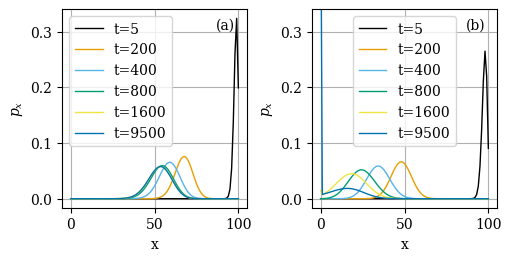

In [28]:
f, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 2.5), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

times = [5, 200, 400, 800, 1600, 9500]

evolutionPlot(ax1, sol_100["40"], times)
evolutionPlot(ax2, sol_100["70"], times)

ax1.annotate("(a)", (0.83, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.83, 0.9), xycoords="axes fraction")

b, t = ax1.get_ylim()

ax2.set_ylim(bottom=b, top=t)

for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
    ax.set_xlabel("x")
    ax.set_ylabel("$p_x$")

plt.savefig("evolution.pdf")

In [29]:
def expPlot(a, sol):
    """plot expected value of sol as a function of time
    returns line2d representing the plotted data"""

    expval = np.array([
        pmfE(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    return a.plot(sol["t"], expval)

def varPlot(a, sol):
    """plot the variance of sol as a function of time
    returns line2d representing the plotted data"""

    vars = np.array([
        pmfVar(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    return a.plot(sol["t"], vars)

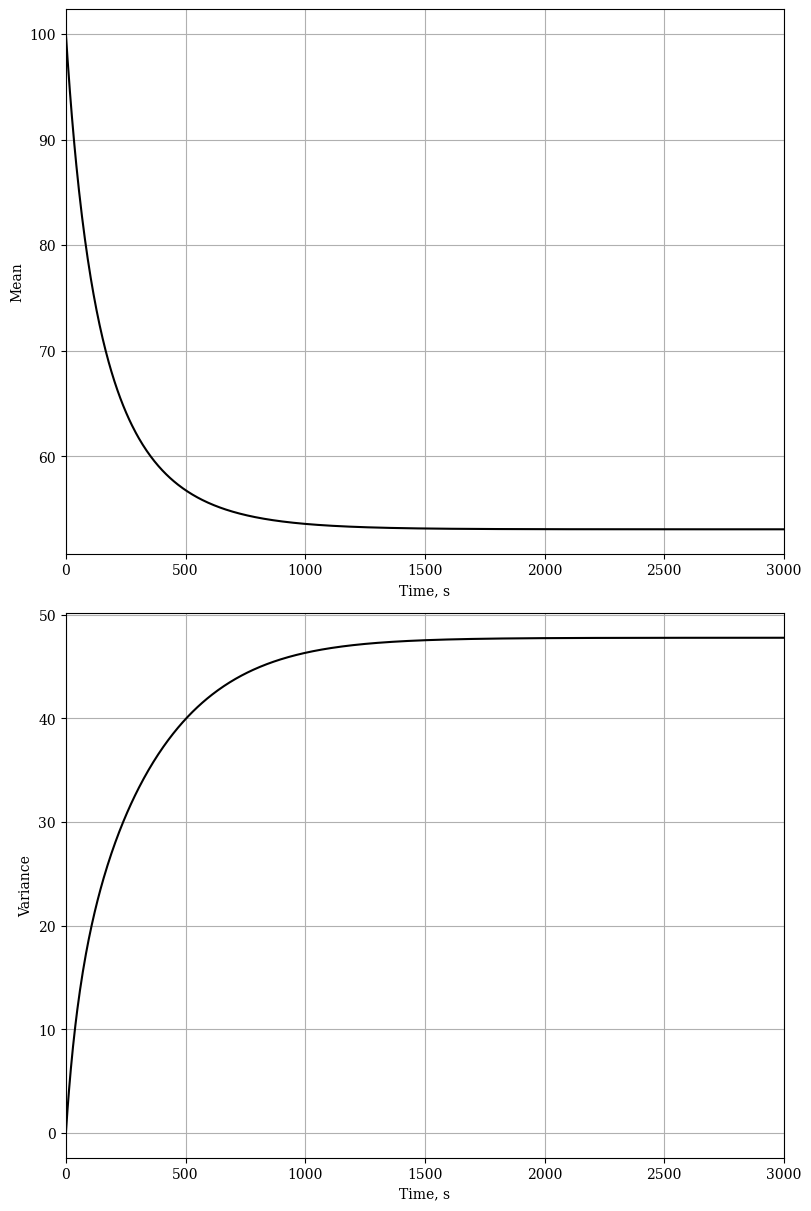

In [30]:
f, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8, 12), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

pt1 = expPlot(ax1, sol_100["40"])

pt3 = varPlot(ax2, sol_100["40"])

ax1.grid(True)
ax1.set_xlabel("Time, s")
ax1.set_ylabel("Mean")
ax1.set_xlim([0, 3000])

ax2.grid(True)
ax2.grid(True)
ax2.set_xlabel("Time, s")
ax2.set_ylabel("Variance")
ax2.set_xlim([0, 3000])

plt.show()

In [31]:
def p0Plot(a, sol):
    return a.plot(sol["t"], sol["y"][0,:])

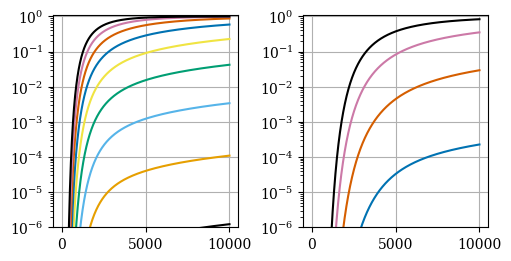

In [32]:
f, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 2.5), layout="constrained")

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

#keys_100 = ["45", "50", "70", "85"]

for i in list(sol_100.keys()):
    p0Plot(ax1, sol_100[i])

for i in list(sol_500.keys()):
    p0Plot(ax2, sol_500[i])

ax1.grid(True)
ax2.grid(True)

ax1.set_yscale("log")
ax2.set_yscale("log")

ax1.set_ylim([10**-6, 1.1])
ax2.set_ylim([10**-6, 1.1])

plt.show()

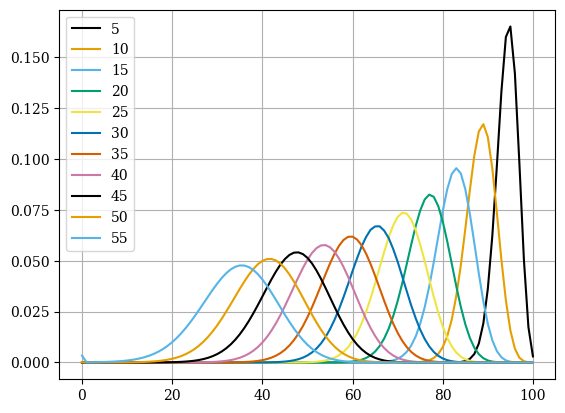

In [33]:
f, ax = plt.subplots()

ax.set_prop_cycle(wong_cycle)

for i in list(sol_100.keys())[0:11]:
    ax.plot(sol_100[i]["y"][:,-1], label=i)

ax.grid(True)
#ax.set_ylim([-0.01, 0.20])
ax.legend()

plt.show()

## Plot expected grass population after 10k seconds as a function of sheep number

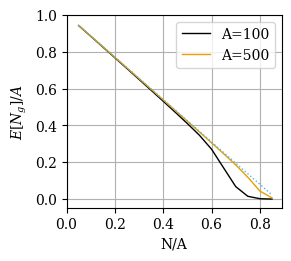

In [34]:
N_A = np.array([int(k) for k in list(sol_100.keys())])/100

det_N_g_100 = np.array(1 - N_A*R/K)

e_10k_100 = np.array([
    pmfE(sol_100[k]["y"][:,-1]) for k in list(sol_100.keys())
])/100

e_10k_500 = np.array([
    pmfE(sol_500[k]["y"][:,-1]) for k in list(sol_500.keys())
])/500

f, ax = plt.subplots(layout="constrained", figsize=(2.8, 2.5))

ax.set_prop_cycle(wong_cycle)

ax.plot(N_A, e_10k_100, "-", label="A=100", linewidth=1)
ax.plot(N_A, e_10k_500, "-", label="A=500", linewidth=1)
ax.plot(N_A, det_N_g_100, ":", linewidth=1)

ax.grid(True)
ax.legend()
ax.set_xlabel("N/A")
ax.set_ylabel("$E[N_g]/A$")
ax.set_xlim(left=0)
ax.set_ylim(top=1)

plt.savefig("expected_N_g_vs_N.pdf")

## Mean time to extinction

In [35]:
def meanExt(N, A):
    """calculate the mean time to extinction for a pasture of size A and sheep population N"""

    r_mod = rMatrix(N, A)[1:,1:]

    m = -np.linalg.inv(r_mod)

    return np.sum(m[-1,:])

large extinction times will cause errors somewhere here - my theory is that `np.linalg.inv()` uses 32 bit floats and starts running into scale limits

In [36]:
N_list_100 = np.arange(85, 35, -1)
N_list_200 = np.arange(170, 100, -2)
N_list_500 = np.arange(425, 300, -5)

mean_ext_100 = np.array([meanExt(i, 100) for i in N_list_100])
mean_ext_200 = np.array([meanExt(i, 200) for i in N_list_200])
mean_ext_500 = np.array([meanExt(i, 500) for i in N_list_500])

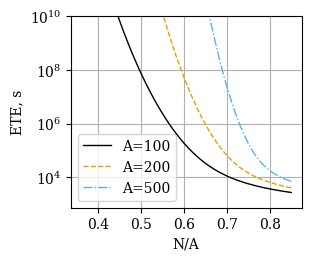

In [37]:
f, ax = plt.subplots(layout="constrained", figsize=(3, 2.5))

ax.set_prop_cycle(wong_cycle)

ax.plot(N_list_100/100, mean_ext_100, "-", label="A=100", linewidth=1)
ax.plot(N_list_200/200, mean_ext_200, "--", label="A=200", linewidth=1)
ax.plot(N_list_500/500, mean_ext_500, "-.", label="A=500", linewidth=1)

ax.set_yscale("log")

ax.set_ylim(top=10**10)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8])
ax.grid(True)
ax.legend(loc="lower left")
ax.set_ylabel("ETE, s")
ax.set_xlabel("N/A")

plt.savefig("ext_time.pdf")

## Quasi-equillibrium distribution

### Recurrence relation method

M. S. Bartlett, J. C. Gower, and P. H. Leslie, A comparison of theoretical and empirical results for some stochastic population models, Biometrika 47: 1-11 (1960)

$$p_x\mu_x=p_{x-1}\lambda_{x-1}$$

$$p_x\mu_x-p_{x-1}\lambda_{x-1}=0$$

for $2\leq x\leq A$

so we will have

$$p_2\mu_2-p_1\lambda_1 = 0$$
$$p_3\mu_3-p_2\lambda_2 = 0$$
$$\dots$$
$$p_A\mu_A-p_{A-1}\lambda_{A-1}=0$$

we also have the equation

$$\sum_{x=1}^{A}p_x=1$$

we will have a system of A equations and A variables

In [38]:
def quasiEqRec(A, N):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

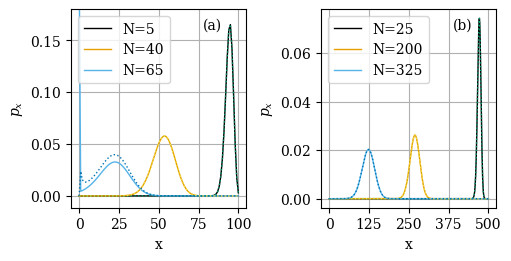

In [39]:
f, (ax, ax2) = plt.subplots(ncols=2, layout="constrained", figsize=(5, 2.5))

ax.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

for i in [5, 40, 65]:
    ax.plot(sol_100[str(i)]["y"][:,-1], label="N={0}".format(i), linewidth=1)

for i in [5, 40, 65]:
    ax.plot(quasiEqRec(100, i), ":", linewidth=1)

for i in [25, 200, 325]:
    ax2.plot(sol_500[str(i)]["y"][:,-1], label="N={0}".format(i), linewidth=1)

for i in [25, 200, 325]:
    ax2.plot(quasiEqRec(500, i), ":", linewidth=1)

ax.grid(True)
ax2.grid(True)

ax.legend(loc="upper left")
ax2.legend()

ax.set_xticks([0, 25, 50, 75, 100])
ax2.set_xticks([0, 125, 250, 375, 500])

ax.set_xlabel("x")
ax2.set_xlabel("x")

ax.set_ylabel("$p_x$")
ax2.set_ylabel("$p_x$")

ax.annotate("(a)", (0.75, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.75, 0.9), xycoords="axes fraction")

ax.set_ylim(top=0.18)

plt.savefig("quasi_eq_comparison.pdf")